In [18]:
from moviad.models.stfpm.stfpm import STFPM
from moviad.utilities.custom_feature_extractor_trimmed import CustomFeatureExtractor
from anomalib.models.image.reverse_distillation.torch_model import ReverseDistillationModel
from moviad.models.fastflow.fastflow import create_fastflow

# student = CustomFeatureExtractor("resnet18", ["layer1", "layer2", "layer3"], device="cuda:0", frozen=False) #128 - 512
# teacher = CustomFeatureExtractor("resnet18", ["layer1", "layer2", "layer3"], device="cuda:0")
# model = STFPM(teacher, student)
# model = ReverseDistillationModel("resnet18", (224, 224), ["layer1", "layer2", "layer3"], "multiply")
model = create_fastflow((224, 224), "resnet18", "cuda:0")

channel:64 scale: 4
channel:128 scale: 8
channel:256 scale: 16


In [19]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 28.454MB


In [20]:
sum(p.numel() for p in model.parameters())

7454528

In [11]:
10.633 + 10.633

21.266

In [19]:
import numpy as np

model_parameters = filter(lambda p: p.requires_grad, teacher.model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])

In [22]:
sum(p.numel() for p in teacher.model.parameters())


2782784

In [1]:
from moviad.datasets.bmad.bmad_dataset import BMAD

train = BMAD('seg', '/mnt/disk1/ruslan_nuriev/bmad', 'retinaoct', 'train')

In [2]:
a = next(iter(train))

In [3]:
import matplotlib.pyplot as plt

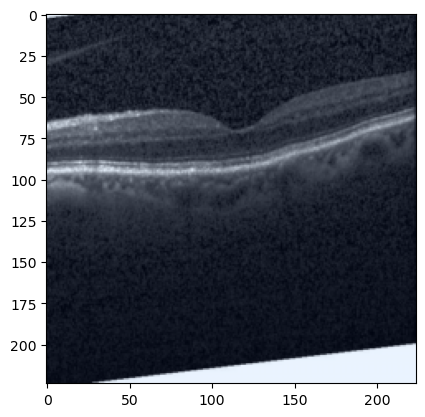

In [4]:
if a.shape[0] == 3:
    img = a.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
else:
    img = a.squeeze().numpy()

plt.imshow(img, cmap='gray' if img.ndim == 2 else None)